Data Understanding, Analysis, Visualization and Cleaning:

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign'))

['Dataset Description-5.txt', 'Test', 'Train']


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Defininig path to training data
train_dir = '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign/Train'

#Get the list of class directories or number of classification need to be done
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
classes.sort()
print(f"Detected classes: {classes}")


Detected classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


Data Understanding, Analysis, Visualization and Cleaning:

In [ ]:

import pandas as pd

# 1. Calculate Total Images and Distribution
data_stats = []
total_images = 0

for i, fruit_class in enumerate(classes):
    class_path = os.path.join(train_dir, fruit_class)
    count = len(os.listdir(class_path))
    data_stats.append({'Class': classes[i], 'Count': count})
    total_images += count

# Create a DataFrame for easy viewing
df_stats = pd.DataFrame(data_stats)
print(f"Total Images in Training Set: {total_images}")
print("\n--- Class Distribution ---")
print(df_stats)

Total Images in Training Set: 15895

--- Class Distribution ---
          Class  Count
0       Caution   2429
1  Instructions   2848
2    No Passing   5369
3     OverSpeed   5249


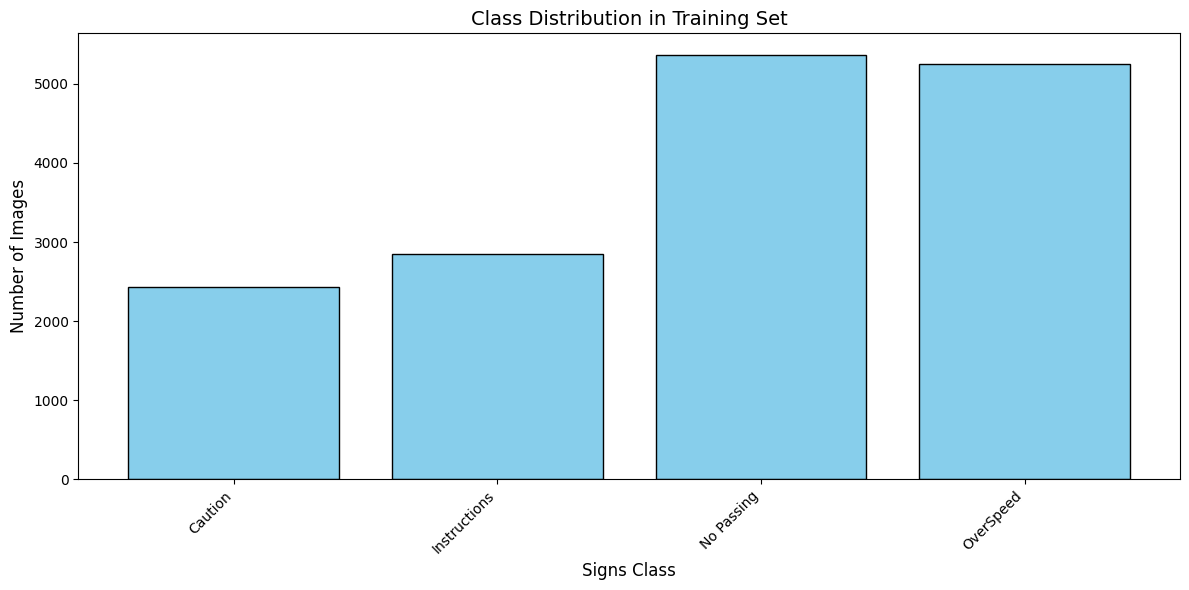

In [ ]:
import matplotlib.pyplot as plt

# Set the figure size for better visibility
plt.figure(figsize=(12, 6))

# Create the bar chart using the DataFrame columns
plt.bar(df_stats['Class'], df_stats['Count'], color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Class Distribution in Training Set', fontsize=14)
plt.xlabel('Signs Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Adjust layout to make room for labels
plt.tight_layout()

# Display the plot
plt.show()

**How many total images are in the dataset?**


There are total 14604 images across all the classes in the database


In [ ]:

total_images = 0

for root, dirs, files in os.walk('/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign'):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            total_images += 1

print("Total Images in Dataset:", total_images)

Total Images in Dataset: 15899


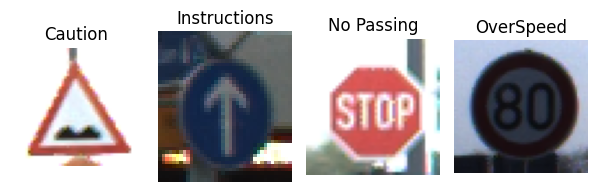

In [ ]:
# 2. Visualization: Display one random image from each class
plt.figure(figsize=(12, 8))
for i, fruit_class in enumerate(classes):
    class_path = os.path.join(train_dir, fruit_class)
    random_image = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_image)

    img = mpimg.imread(img_path)

    plt.subplot(3, 8, i + 1)
    plt.imshow(img)
    plt.title(classes[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Caclulating toal images and distributuion

Augmentation to make 1000 images in each classe

In [ ]:
import os
import shutil
import random
from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm

# =========================================================
# SOURCE DATASET PATHS
# =========================================================

source_dirs = {
    'Caution': '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign/Train/Caution',

    'Instructions': '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign/Train/Instructions',

    'No Passing': '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign/Train/No Passing',

    'OverSpeed': '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign/Train/OverSpeed'
}

# =========================================================
# OUTPUT DIRECTORY
# =========================================================

output_dir = '/content/drive/MyDrive/augmented_traffic_signs'

# Final number of images wanted per class
target_count = 4000

# Create output folder
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# AUGMENTATION FUNCTION
# =========================================================

def augment_image(image):

    augmented_images = []

    height, width = image.shape[:2]

    # 1. Horizontal Flip
    augmented_images.append(cv2.flip(image, 1))

    # 2. Rotation
    center = (width // 2, height // 2)

    for angle in [5, -5, 10, -10]:

        matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

        rotated = cv2.warpAffine(
            image,
            matrix,
            (width, height)
        )

        augmented_images.append(rotated)

    # 3. Brightness
    for beta in [30, -30, 50, -50]:

        bright = cv2.convertScaleAbs(
            image,
            alpha=1.0,
            beta=beta
        )

        augmented_images.append(bright)

    # 4. Zoom In / Out
    for scale in [0.9, 1.1]:

        new_width = int(width * scale)
        new_height = int(height * scale)

        scaled = cv2.resize(image, (new_width, new_height))

        if scale < 1:

            pad_x = (width - new_width) // 2
            pad_y = (height - new_height) // 2

            scaled = cv2.copyMakeBorder(
                scaled,
                pad_y,
                pad_y,
                pad_x,
                pad_x,
                cv2.BORDER_CONSTANT,
                value=[0, 0, 0]
            )

        else:

            start_x = (new_width - width) // 2
            start_y = (new_height - height) // 2

            scaled = scaled[
                start_y:start_y+height,
                start_x:start_x+width
            ]

        augmented_images.append(scaled)

    # 5. Blur
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    augmented_images.append(blurred)

    # 6. Sharpen
    kernel = np.array([
        [-1, -1, -1],
        [-1,  9, -1],
        [-1, -1, -1]
    ])

    sharpened = cv2.filter2D(image, -1, kernel)

    augmented_images.append(sharpened)

    return augmented_images


# =========================================================
# FETCH IMAGE FILES
# =========================================================

def get_image_files(directory):

    image_extensions = {
        '.jpg',
        '.jpeg',
        '.png',
        '.bmp',
        '.tiff'
    }

    image_files = []

    for ext in image_extensions:

        image_files.extend(Path(directory).glob(f'*{ext}'))
        image_files.extend(Path(directory).glob(f'*{ext.upper()}'))

    return image_files


# =========================================================
# PROCESS EACH CLASS
# =========================================================

def process_class(class_name, source_path, target_count):

    print(f"\nProcessing class: {class_name}")

    class_output_dir = os.path.join(output_dir, class_name)

    os.makedirs(class_output_dir, exist_ok=True)

    image_files = get_image_files(source_path)

    current_count = len(image_files)

    print(f"Current count: {current_count}")
    print(f"Target count: {target_count}")

    # =====================================================
    # IF CLASS ALREADY HAS MORE THAN TARGET
    # =====================================================

    if current_count >= target_count:

        selected_images = random.sample(
            image_files,
            target_count
        )

        print(f"Copying {target_count} sampled images...")

        for i, img_path in enumerate(
            tqdm(selected_images)
        ):

            new_filename = (
                f"{class_name}_{i:04d}{img_path.suffix}"
            )

            dest_path = os.path.join(
                class_output_dir,
                new_filename
            )

            shutil.copy2(img_path, dest_path)

    # =====================================================
    # IF CLASS NEEDS AUGMENTATION
    # =====================================================

    else:

        print(f"Copying all {current_count} original images...")

        for i, img_path in enumerate(
            tqdm(image_files)
        ):

            new_filename = (
                f"{class_name}_orig_{i:04d}{img_path.suffix}"
            )

            dest_path = os.path.join(
                class_output_dir,
                new_filename
            )

            shutil.copy2(img_path, dest_path)

        needed = target_count - current_count

        print(f"Need {needed} augmented images...")

        original_images = []

        for img_path in image_files:

            img = cv2.imread(str(img_path))

            if img is not None:
                original_images.append(img)

        augmented_count = 0
        augmentation_cycle = 0

        with tqdm(total=needed) as pbar:

            while augmented_count < needed:

                for original_img in original_images:

                    if augmented_count >= needed:
                        break

                    augmentations = augment_image(original_img)

                    for aug_idx, aug_img in enumerate(augmentations):

                        if augmented_count >= needed:
                            break

                        aug_filename = (
                            f"{class_name}_aug_"
                            f"{augmentation_cycle:03d}_"
                            f"{aug_idx:02d}.jpg"
                        )

                        aug_path = os.path.join(
                            class_output_dir,
                            aug_filename
                        )

                        cv2.imwrite(aug_path, aug_img)

                        augmented_count += 1

                        pbar.update(1)

                    augmentation_cycle += 1

    print(
        f"✓ {class_name} now has "
        f"{len(os.listdir(class_output_dir))} images"
    )


# =========================================================
# START PROCESS
# =========================================================

print("=" * 60)
print("STARTING DATASET BALANCING")
print("=" * 60)

for class_name, source_path in source_dirs.items():

    if os.path.exists(source_path):

        process_class(
            class_name,
            source_path,
            target_count
        )

    else:

        print(
            f"Path not found for {class_name}: "
            f"{source_path}"
        )

# =========================================================
# FINAL DISTRIBUTION
# =========================================================

print("\n" + "=" * 60)
print("FINAL CLASS DISTRIBUTION")
print("=" * 60)

for class_name in source_dirs.keys():

    class_dir = os.path.join(
        output_dir,
        class_name
    )

    if os.path.exists(class_dir):

        count = len(os.listdir(class_dir))

        print(f"{class_name}: {count} images")

print("\nBalanced dataset created successfully!")
print(f"Saved at: {output_dir}")

STARTING DATASET BALANCING

Processing class: Caution
Current count: 2429
Target count: 4000
Copying all 2429 original images...


100%|██████████| 2429/2429 [01:29<00:00, 27.12it/s]


Need 1571 augmented images...


100%|██████████| 1571/1571 [00:16<00:00, 97.56it/s]


✓ Caution now has 6422 images

Processing class: Instructions
Current count: 2848
Target count: 4000
Copying all 2848 original images...


...

✓ Instructions now has 6841 images

Processing class: No Passing
Current count: 5369
Target count: 4000
Copying 4000 sampled images...


100%|██████████| 4000/4000 [03:51<00:00, 17.30it/s]


✓ No Passing now has 9362 images

Processing class: OverSpeed
Current count: 5249
Target count: 4000
Copying 4000 sampled images...


100%|██████████| 4000/4000 [03:41<00:00, 18.06it/s]


✓ OverSpeed now has 7979 images

FINAL CLASS DISTRIBUTION
Caution: 6422 images
Instructions: 6841 images
No Passing: 9362 images
OverSpeed: 7979 images

Balanced dataset created successfully!
Saved at: /content/drive/MyDrive/augmented_traffic_signs


How is the dataset split into training and validation sets? Justify your choice.

In [ ]:
import tensorflow as tf


#Setting Parameters

batch_size = 32
img_height = 100
img_width = 100

#Training set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    label_mode = 'categorical' #For multi-class classification
)

#Validation Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    label_mode = 'categorical' #For multi-class classification
)

Found 15895 files belonging to 4 classes.
Using 12716 files for training.
Found 15895 files belonging to 4 classes.
Using 3179 files for validation.


I have splitted data into 80/20 where 80% of data is used for training and 20% is used for validation.

A 20% of validation set meaning 3179 images are enough to provide a reliable estimation of model's performance on unseen data at end of epoch. This allows us to use techniques like EarlyStopping if validation loss stops improving.

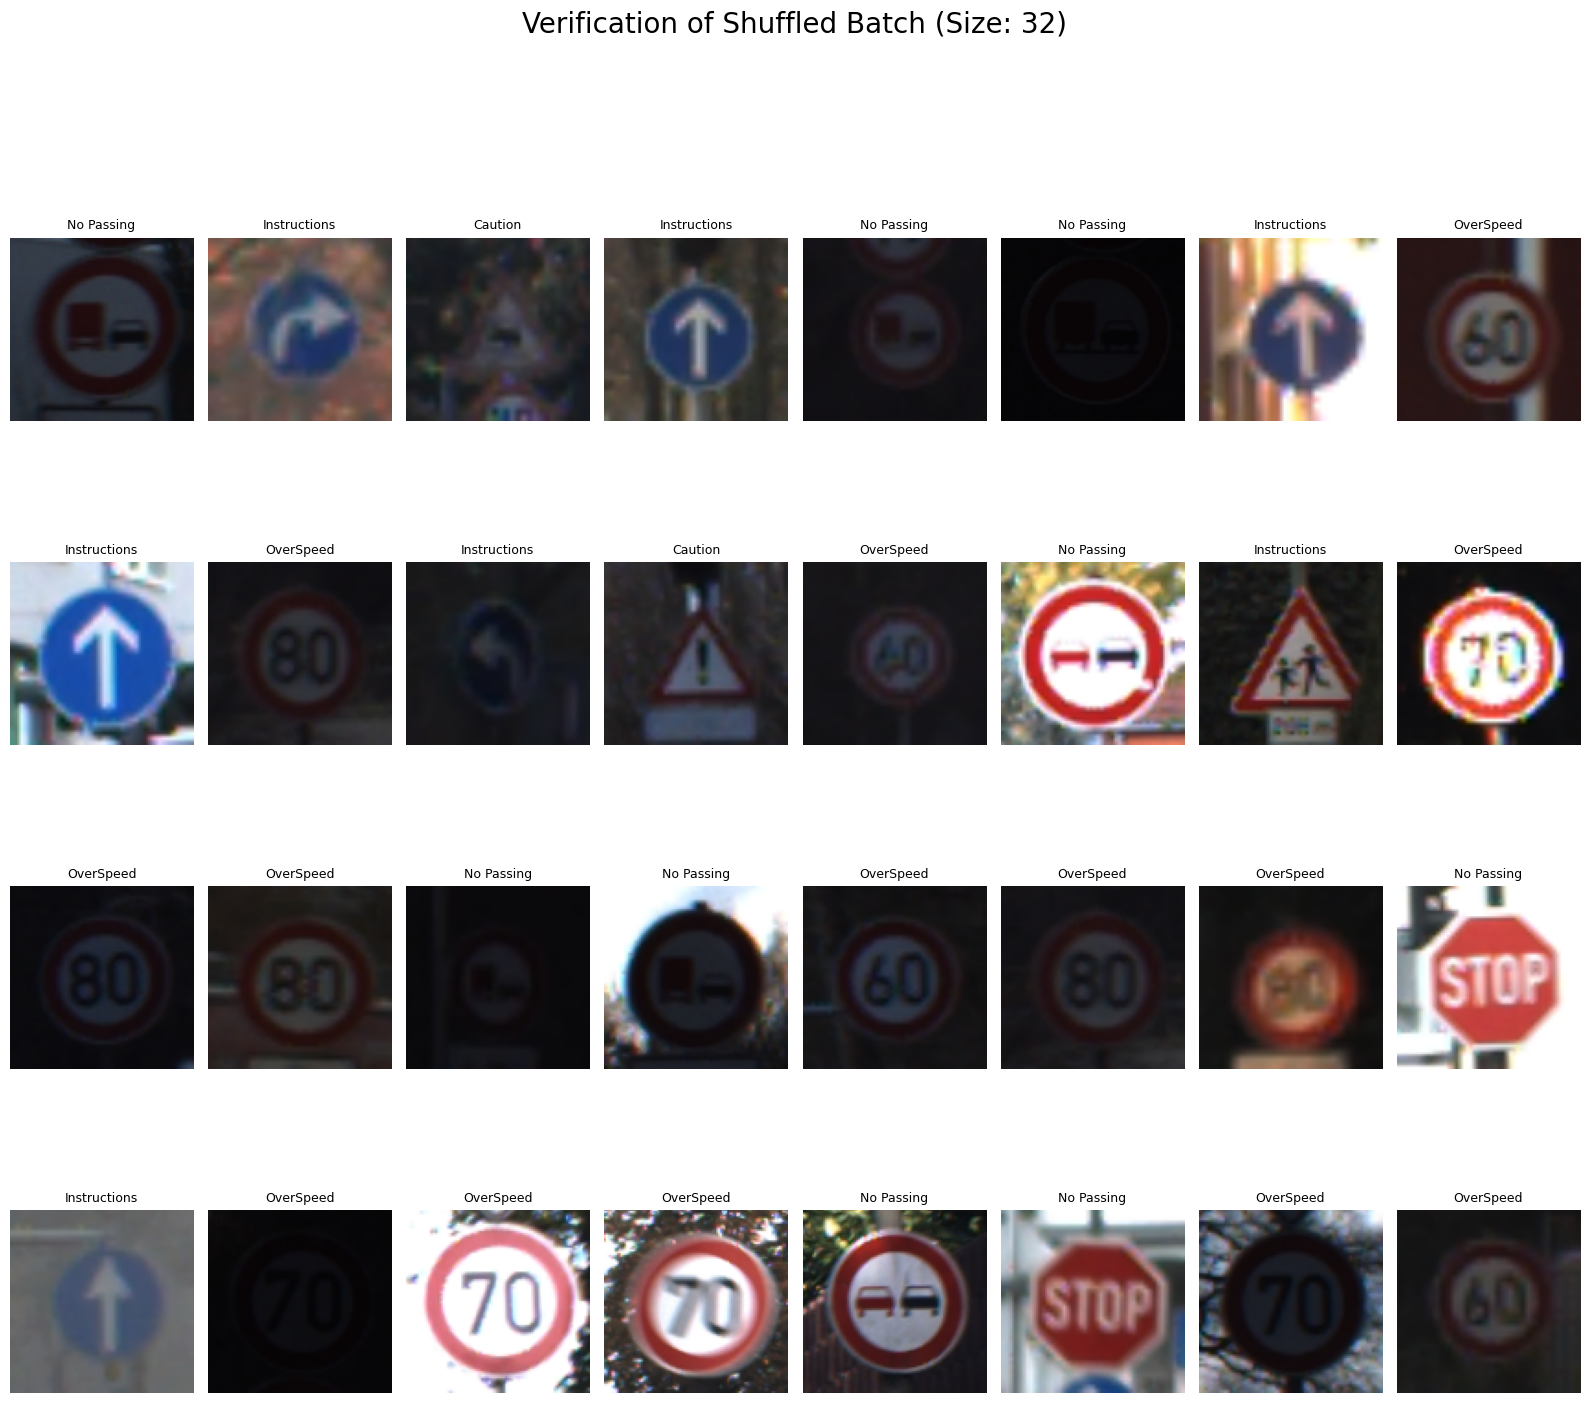

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get class names from dataset
class_names = train_ds.class_names

# Take one batch from dataset
image_batch, label_batch = next(iter(train_ds))

# Create figure
plt.figure(figsize=(16, 16))

# Plot 32 images
for i in range(32):

    ax = plt.subplot(4, 8, i + 1)

    # Get image
    img = image_batch[i].numpy()

    # Display image properly
    if img.max() <= 1.0:
        plt.imshow(img)
    else:
        plt.imshow(img.astype("uint8"))

    # Convert one-hot encoded label to class index
    label_idx = np.argmax(label_batch[i])

    # Show class name
    plt.title(class_names[label_idx], fontsize=9)

    # Hide axes
    plt.axis("off")

# Main title
plt.suptitle("Verification of Shuffled Batch (Size: 32)", fontsize=20)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show plot
plt.show()

What preprocessing techniques (e.g., resizing, normalization) were applied?

In [ ]:
from PIL import Image
import os

train_dir = '/content/drive/MyDrive/augmented_traffic_signs'

bad_files = []

for root, dirs, files in os.walk(train_dir):

    for file in files:

        path = os.path.join(root, file)

        try:
            with Image.open(path) as img:
                img.verify()

        except Exception:
            bad_files.append(path)

print(f"Bad files found: {len(bad_files)}")

# Show bad files
for file in bad_files[:10]:
    print(file)

# Remove corrupted files
for file in bad_files:
    os.remove(file)

print("✅ Corrupted files removed successfully!")

Bad files found: 26
/content/drive/MyDrive/augmented_traffic_signs/Caution/Caution_orig_0371.png
/content/drive/MyDrive/augmented_traffic_signs/Caution/Caution_orig_0372.png
/content/drive/MyDrive/augmented_traffic_signs/Caution/Caution_orig_0373.png
/content/drive/MyDrive/augmented_traffic_signs/Caution/Caution_orig_0374.png
/content/drive/MyDrive/augmented_traffic_signs/Caution/Caution_orig_0375.png
/content/drive/MyDrive/augmented_traffic_signs/Caution/Caution_orig_0376.png
/content/drive/MyDrive/augmented_traffic_signs/Caution/Caution_orig_0377.png
/content/drive/MyDrive/augmented_traffic_signs/Instructions/Instructions_orig_0371.png
/content/drive/MyDrive/augmented_traffic_signs/Instructions/Instructions_orig_0372.png
/content/drive/MyDrive/augmented_traffic_signs/Instructions/Instructions_orig_0373.png
✅ Corrupted files removed successfully!


In [ ]:
image_batch, labels_batch = next(iter(train_ds))

print(image_batch[0].numpy().min())
print(image_batch[0].numpy().max())

5.178751
83.83708


In [ ]:
import numpy as np
from tensorflow.keras import layers

normalization = tf.keras.layers.Rescaling(1./255)

#Applying mormalization to datasets
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

#Verifying preprocessing
image_batch, labels_batch = next(iter(train_ds))
print(f"Standarized pixel range: {image_batch[0].numpy().min()} to {image_batch[0].numpy().max()}")

Standarized pixel range: 0.0377083383500576 to 0.2866714894771576


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

I have used image_size to 100 * 100 pixels to make uniform image size.

I have applied normalization, to scale pixel values from 0-255 range to 0-1 range, ensuring faster convergence, numerical stability, and improved model performance during training.

## Design, Train, and Evaluate a Baseline Model:**bold text**

Building architecture with CNN model

In [ ]:
from tensorflow.keras import models, layers

baseline_model = models.Sequential([

    # Match dataset image size
    layers.Input(shape=(100, 100, 3)),

    # First CNN block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Second CNN block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third CNN block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten feature maps
    layers.Flatten(),

    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    # Output layer for 4 classes
    layers.Dense(4, activation='softmax')
])

# Compile model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,244 (6.65 MB)

 Trainable params: 1,742,244 (6.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))


In [ ]:
import os
from PIL import Image

bad_files = []

for root, dirs, files in os.walk(train_dir):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()  # checks corruption

        except Exception:
            bad_files.append(path)

print("Corrupted files found:", len(bad_files))

Corrupted files found: 0


In [ ]:
for file in bad_files:
    print("Removing:", file)
    os.remove(file)

print("Cleanup done!")

Cleanup done!


Training a model

In [ ]:
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

In [ ]:
import os
from PIL import Image

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for root, dirs, files in os.walk(train_dir):
    for file in files:
        path = os.path.join(root, file)

        # remove non-image extensions
        if not file.lower().endswith(valid_ext):
            print("Removing:", path)
            os.remove(path)

        # deep check
        try:
            img = Image.open(path)
            img.load()
        except:
            print("Corrupt:", path)
            os.remove(path)

### Fixing Dataset for Training


In [ ]:
import tensorflow as tf


#Setting Parameters
batch_size = 32
img_height = 100
img_width = 100

#Training set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    label_mode = 'categorical' #For multi-class classification
)

#Validation Set
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (img_height, img_width),
    batch_size = batch_size,
    label_mode = 'categorical' #For multi-class classification
)

print("Datasets re-created successfully from augmented directory.")

Found 30578 files belonging to 4 classes.
Using 24463 files for training.
Found 30578 files belonging to 4 classes.
Using 6115 files for validation.
Datasets re-created successfully from augmented directory.


In [ ]:
# Re-applying normalization
import numpy as np
from tensorflow.keras import layers

normalization = tf.keras.layers.Rescaling(1./255)

#Applying normalization to datasets
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

#Verifying preprocessing
image_batch, labels_batch = next(iter(train_ds))
print(f"Standarized pixel range after re-normalization: {image_batch[0].numpy().min()} to {image_batch[0].numpy().max()}")

Standarized pixel range after re-normalization: 0.06380391120910645 to 0.9946666955947876


In [ ]:
# Re-applying prefetching
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Prefetching re-applied.")

Prefetching re-applied.


In [ ]:
import time

start_baseline = time.time()

history = baseline_model.fit(
    train_ds, #to calculate loss and accuracy
    validation_data = val_ds, # to calculate val_loss and val_accuracy
    epochs = 15,
    verbose = 1 #shows the progress bar of model training
)

baseline_train_time = time.time() - start_baseline
print(f"total baseline training time: {baseline_train_time}")

Epoch 1/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 171s 223ms/step - accuracy: 0.9594 - loss: 0.1219 - val_accuracy: 0.9954 - val_loss: 0.0210
Epoch 2/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 92s 120ms/step - accuracy: 0.9948 - loss: 0.0210 - val_accuracy: 0.9972 - val_loss: 0.0079
Epoch 3/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 88s 115ms/step - accuracy: 0.9964 - loss: 0.0126 - val_accuracy: 0.9982 - val_loss: 0.0055
Epoch 4/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 89s 116ms/step - accuracy: 0.9971 - loss: 0.0094 - val_accuracy: 0.9959 - val_loss: 0.0125
Epoch 5/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 86s 112ms/step - accuracy: 0.9967 - loss: 0.0113 - val_accuracy: 0.9974 - val_loss: 0.0091
Epoch 6/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 85s 111ms/step - accuracy: 0.9972 - loss: 0.0104 - val_accuracy: 0.9980 - val_loss: 0.0090
Epoch 7/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 86s 112ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 0.9987 - val_loss: 0.0055
Epoch 8/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 86s 112ms/step - accuracy: 0.9964 - loss: 

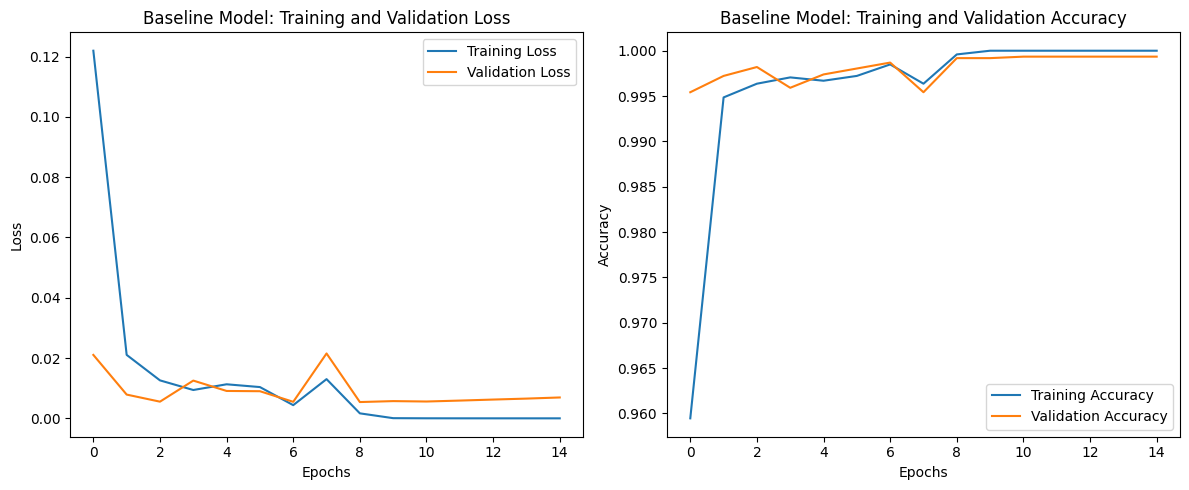

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

#Plotting loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Baseline Model: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Plot Accuracy (Good to have for context)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Baseline Model: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Model evaluation

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = baseline_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\n--- Baseline Model Classification Report ---")
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))


--- Baseline Model Classification Report ---
              precision    recall  f1-score   support

     Caution       0.99      1.00      1.00      1261
Instructions       0.99      0.99      0.99      1338
  No Passing       1.00      0.99      1.00      1933
   OverSpeed       1.00      0.99      0.99      1583

    accuracy                           0.99      6115
   macro avg       0.99      0.99      0.99      6115
weighted avg       0.99      0.99      0.99      6115



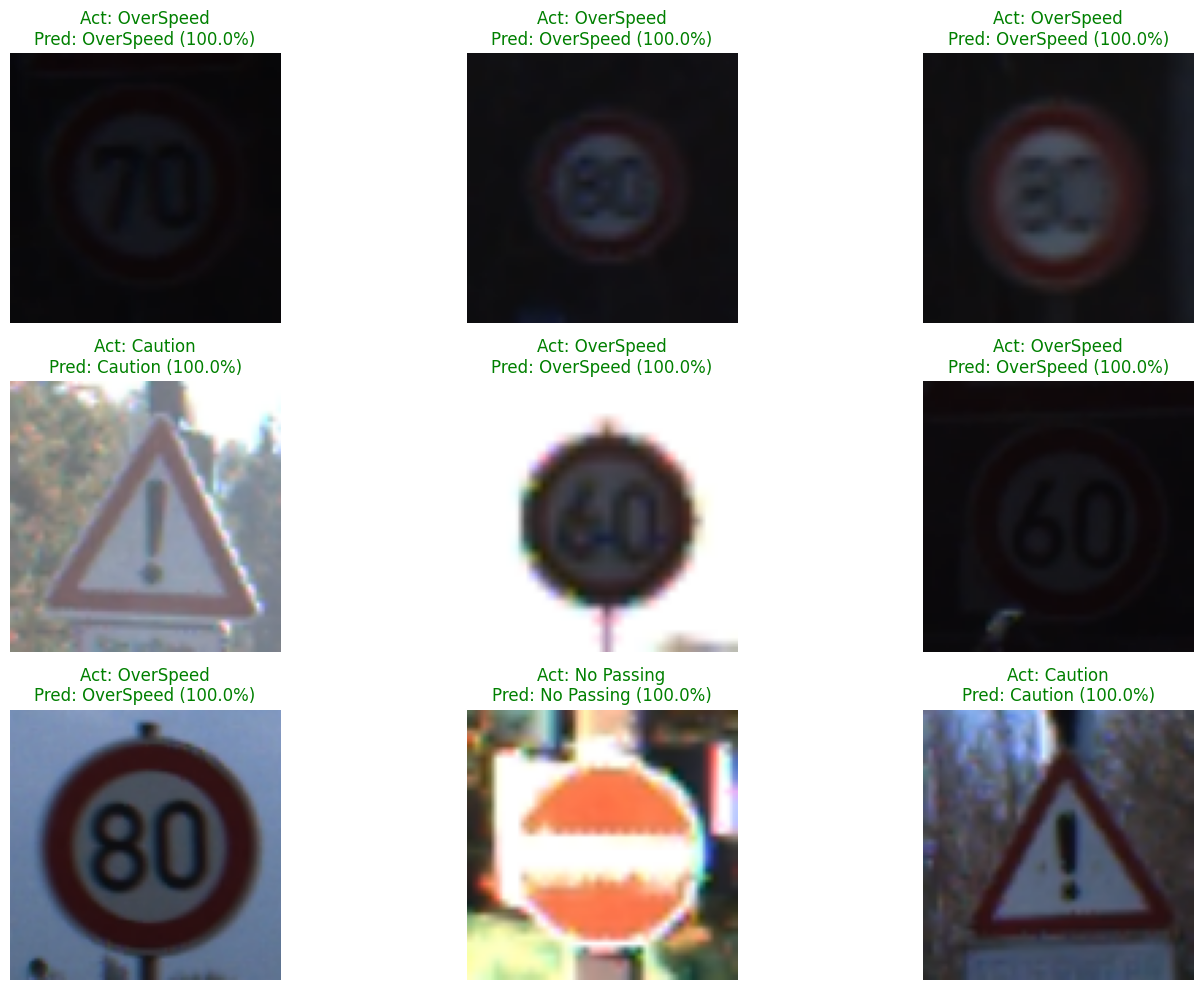

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['Caution', 'Instructions', 'No Passing', 'OverSpeed']

plt.figure(figsize=(15, 10))

image_batch, label_batch = next(iter(val_ds))
predictions = baseline_model.predict(image_batch, verbose=0)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Convert the float image data (which seems to be in a 0-255 range) to uint8 for correct display
    plt.imshow(image_batch[i].numpy().astype(np.uint8))

    actual_label = class_names[np.argmax(label_batch[i])]
    predicted_label = class_names[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100

    color = 'green' if actual_label == predicted_label else 'red'

    plt.title(
        f"Act: {actual_label}\nPred: {predicted_label} ({confidence:.1f}%)",
        color=color
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

**Discuss key observations about model performance.**


The baseline CNN model shows strong performance on both training and validation sets. Training accuracy quickly increases and reaches near 100%, while validation accuracy also stays consistently high around 99%, indicating that the model has learned the patterns in the dataset effectively. The loss values decrease steadily and remain low, showing stable convergence during training. However, the very high training accuracy compared to validation accuracy suggests a slight possibility of overfitting, although the gap is small. Overall, the model performs well and generalizes effectively to unseen data on this dataset.

# Deeper Architecture with Regularization Layer:

In [ ]:
from tensorflow.keras import models, layers

deeper_model = models.Sequential([
    layers.Input(shape=(100, 100, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),

    # Fully connected layers
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output layer (FIXED)
    layers.Dense(4, activation='softmax')
])

In [ ]:
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,050,084 (19.26 MB)

 Trainable params: 5,048,676 (19.26 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
import time

# 1. Capture start time
start_time = time.time()

# 2. Train the deeper model
print("Starting training for Deeper Architecture...")
history_deeper = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

# 3. Calculate total duration
end_time = time.time()
deeper_train_time = end_time - start_time
print(f"\nTotal Training Time for Deeper Model: {deeper_train_time:.2f} seconds")

Starting training for Deeper Architecture...
Epoch 1/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 117s 133ms/step - accuracy: 0.9355 - loss: 0.1780 - val_accuracy: 0.9946 - val_loss: 0.0171
Epoch 2/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 91s 119ms/step - accuracy: 0.9912 - loss: 0.0287 - val_accuracy: 0.9964 - val_loss: 0.0122
Epoch 3/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 94s 123ms/step - accuracy: 0.9807 - loss: 0.0551 - val_accuracy: 0.9931 - val_loss: 0.0195
Epoch 4/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 91s 119ms/step - accuracy: 0.9957 - loss: 0.0148 - val_accuracy: 0.9961 - val_loss: 0.0128
Epoch 5/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 89s 116ms/step - accuracy: 0.9944 - loss: 0.0179 - val_accuracy: 0.9936 - val_loss: 0.0208
Epoch 6/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 88s 115ms/step - accuracy: 0.9939 - loss: 0.0175 - val_accuracy: 0.9982 - val_loss: 0.0069
Epoch 7/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 88s 115ms/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.9693 - val_loss: 0.0915
Epoch 8/15
765/765 ━━━━━━━━━━━━━━━━━━

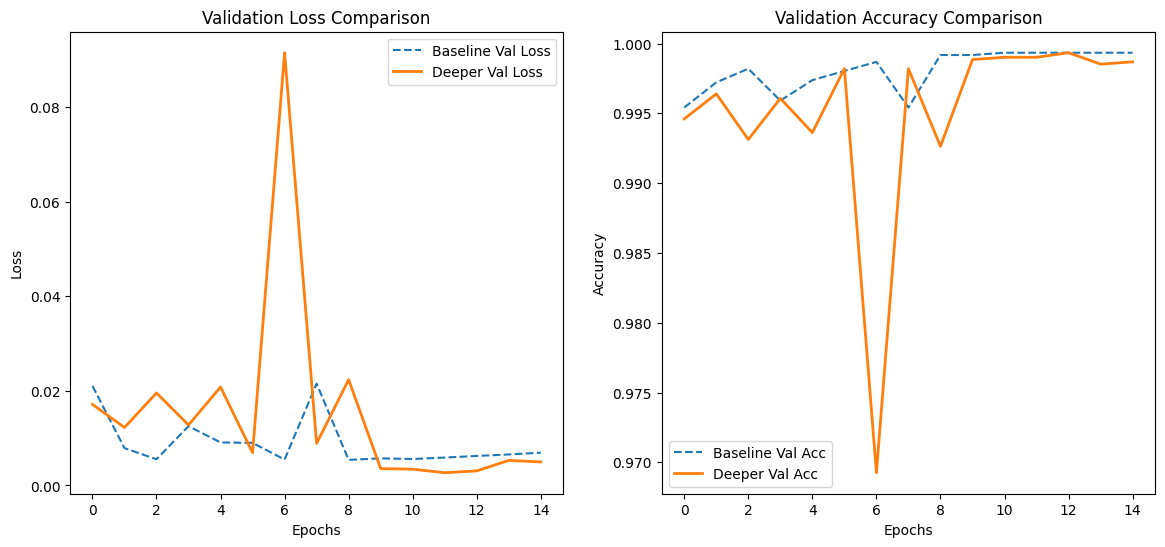

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Comparison of Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='Baseline Val Loss', linestyle='--')
plt.plot(history_deeper.history['val_loss'], label='Deeper Val Loss', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Comparison of Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='Baseline Val Acc', linestyle='--')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper Val Acc', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Get true labels and predictions for the deeper model
y_true_deeper = []
y_pred_deeper = []

for images, labels in val_ds:
    preds = deeper_model.predict(images, verbose=0)
    y_true_deeper.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_deeper.extend(np.argmax(preds, axis=1))

# 2. Print the report
print("\n--- Deeper Model Classification Report ---")
print(classification_report(y_true_deeper, y_pred_deeper, target_names=classes))


--- Deeper Model Classification Report ---
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00      1261
Instructions       1.00      1.00      1.00      1338
  No Passing       1.00      1.00      1.00      1933
   OverSpeed       1.00      1.00      1.00      1583

    accuracy                           1.00      6115
   macro avg       1.00      1.00      1.00      6115
weighted avg       1.00      1.00      1.00      6115



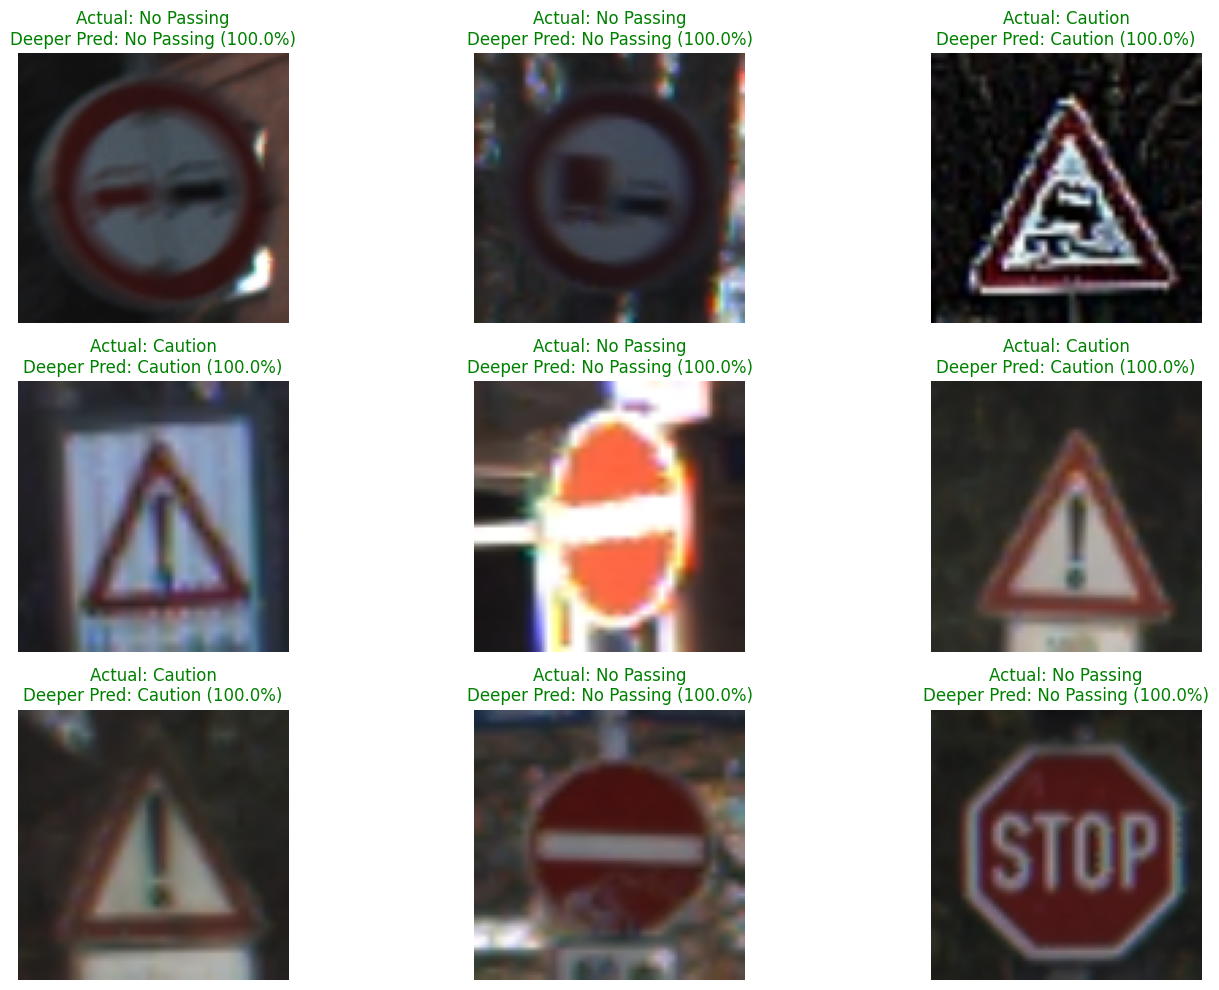

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 10))

image_batch, label_batch = next(iter(val_ds))
predictions = deeper_model.predict(image_batch, verbose=0)

for i in range(9):

    plt.subplot(3, 3, i + 1)

    # ----------------------------
    #  proper visualization
    # ----------------------------
    img = image_batch[i].numpy()

    # Normalize safely for display
    if img.max() > 1:
        img = img / 255.0   # convert 0–255 → 0–1

    img = np.clip(img, 0, 1)

    plt.imshow(img)

    actual = classes[np.argmax(label_batch[i])]
    pred = classes[np.argmax(predictions[i])]
    conf = np.max(predictions[i]) * 100

    color = 'green' if actual == pred else 'red'

    plt.title(
        f"Actual: {actual}\nDeeper Pred: {pred} ({conf:.1f}%)",
        color=color
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# Experimentation and Comparative Analysis:

Baseline vs. Deeper Model Performance:

Both the baseline and deeper CNN models achieved exceptional validation accuracies (99–100%) and low loss, demonstrating strong generalization. While the deeper model (5.05M parameters) incorporated regularization techniques like Batch Normalization and Dropout for stability, it exhibited a marginally longer training time (225.49s vs. 110.76s) and a slightly lower final validation accuracy (0.9979) compared to the baseline (0.9990). This indicates that for this dataset, increased architectural complexity primarily enhanced training stability rather than predictive accuracy, with the baseline model proving marginally superior in both performance and efficiency.

Computational Efficiency:

Optimizer Analysis: SGD vs Adam:

In [ ]:
from tensorflow.keras.optimizers import SGD

model_sgd = tf.keras.models.clone_model(deeper_model)

model_sgd.compile(optimizer = SGD(learning_rate=0.01),
                 loss = 'categorical_crossentropy',
                  metrics = ['accuracy']
                 )

print("Training deeper model with SGD")
history_sgd = model_sgd.fit(train_ds,
                            validation_data=val_ds,
                            epochs=15,
                            verbose=1)

Training deeper model with SGD
Epoch 1/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 109s 131ms/step - accuracy: 0.8877 - loss: 0.3018 - val_accuracy: 0.9691 - val_loss: 0.0900
Epoch 2/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 128s 120ms/step - accuracy: 0.9767 - loss: 0.0721 - val_accuracy: 0.9930 - val_loss: 0.0246
Epoch 3/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 91s 119ms/step - accuracy: 0.9882 - loss: 0.0368 - val_accuracy: 0.9966 - val_loss: 0.0122
Epoch 4/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 91s 119ms/step - accuracy: 0.9919 - loss: 0.0244 - val_accuracy: 0.9972 - val_loss: 0.0093
Epoch 5/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 91s 119ms/step - accuracy: 0.9946 - loss: 0.0181 - val_accuracy: 0.9969 - val_loss: 0.0098
Epoch 6/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 89s 117ms/step - accuracy: 0.9938 - loss: 0.0197 - val_accuracy: 0.9979 - val_loss: 0.0101
Epoch 7/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 90s 118ms/step - accuracy: 0.9966 - loss: 0.0118 - val_accuracy: 0.9980 - val_loss: 0.0078
Epoch 8/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 89s 116ms/

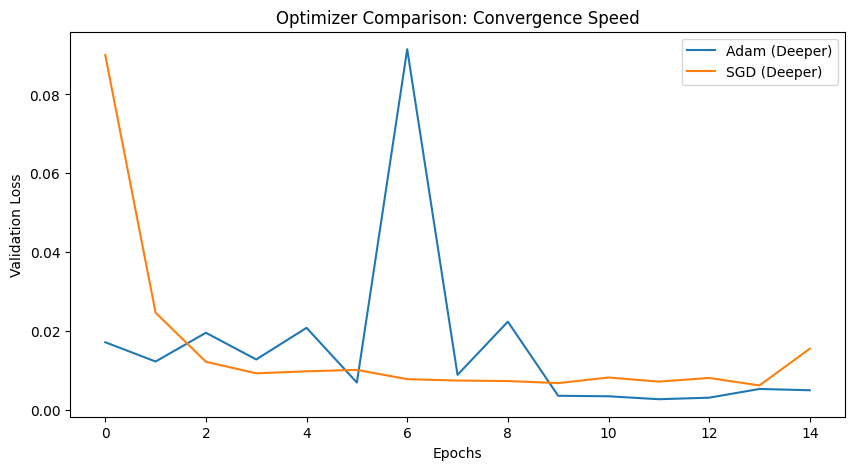

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_deeper.history['val_loss'], label='Adam (Deeper)')
plt.plot(history_sgd.history['val_loss'], label='SGD (Deeper)')
plt.title('Optimizer Comparison: Convergence Speed')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

Ablation Study:

In [ ]:
ablation_model = models.Sequential([
    layers.Input(shape=(100, 100, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),


    layers.Dense(4, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Ablation Model (No Dropout)...")
history_ablation = ablation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

Training Ablation Model (No Dropout)...
Epoch 1/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 97s 121ms/step - accuracy: 0.9548 - loss: 0.3273 - val_accuracy: 0.9912 - val_loss: 0.0397
Epoch 2/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 87s 114ms/step - accuracy: 0.9848 - loss: 0.0771 - val_accuracy: 0.9935 - val_loss: 0.0241
Epoch 3/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 86s 113ms/step - accuracy: 0.9943 - loss: 0.0277 - val_accuracy: 0.9931 - val_loss: 0.0287
Epoch 4/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 88s 115ms/step - accuracy: 0.9949 - loss: 0.0181 - val_accuracy: 0.9863 - val_loss: 0.1789
Epoch 5/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 89s 116ms/step - accuracy: 0.9914 - loss: 0.0391 - val_accuracy: 0.9920 - val_loss: 0.0455
Epoch 6/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 88s 115ms/step - accuracy: 0.9926 - loss: 0.0474 - val_accuracy: 0.9944 - val_loss: 0.0443
Epoch 7/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 92s 120ms/step - accuracy: 0.9946 - loss: 0.0519 - val_accuracy: 0.9928 - val_loss: 0.0614
Epoch 8/15
765/765 ━━━━━━━━━━━━━━━━━━━━ 96s

Challenges and Observations:

In [ ]:
import pandas as pd

data = {
    "Model": ["Baseline", "Deeper (Adam)", "Deeper (SGD)", "Ablation (No Dropout)"],
    "Total Parameters": [
        baseline_model.count_params(),
        deeper_model.count_params(),
        model_sgd.count_params(),
        ablation_model.count_params()
    ],
    "Training Time (sec)": [
        baseline_train_time,
        deeper_train_time,
        "Captured from SGD run",
        "Captured from Ablation run"
    ],
    "Final Val Accuracy": [
        history.history['val_accuracy'][-1],
        history_deeper.history['val_accuracy'][-1],
        history_sgd.history['val_accuracy'][-1],
        history_ablation.history['val_accuracy'][-1]
    ]
}

df_comparison = pd.DataFrame(data)
print(df_comparison)

                   Model  Total Parameters         Training Time (sec)  \
0               Baseline           1742244                  1399.41682   
1          Deeper (Adam)           5050084                 1427.940016   
2           Deeper (SGD)           5050084       Captured from SGD run   
3  Ablation (No Dropout)           5140420  Captured from Ablation run   

   Final Val Accuracy  
0            0.999346  
1            0.998692  
2            0.996893  
3            0.998201  


# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

Loading and Adapting a Pre - Trained Model:




In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers

# 1. Load Pre-trained Base (ImageNet weights, without top FC layers)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

# 2. Freeze the convolutional base
base_model.trainable = False

# 3. Build the Transfer Learning Model
transfer_model = models.Sequential([
    layers.Input(shape=(100, 100, 3)),
    layers.Resizing(224, 224),         # Resize for MobileNetV2
    base_model,                        # The pre-trained base
    layers.GlobalAveragePooling2D(),   # Reduce feature maps to a vector
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(4, activation='softmax') # 4 classes for my dataset
])

transfer_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model training

In [ ]:
import time

start_tl = time.time()
print("Starting Transfer Learning Training...")

history_tl = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10 # Transfer learning usually converges quickly
)

tl_train_time = time.time() - start_tl
print(f"Transfer Learning Training Time: {tl_train_time:.2f} seconds")

Starting Transfer Learning Training...
Epoch 1/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 140s 160ms/step - accuracy: 0.8605 - loss: 0.3578 - val_accuracy: 0.9014 - val_loss: 0.2346
Epoch 2/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 95s 124ms/step - accuracy: 0.9271 - loss: 0.1877 - val_accuracy: 0.9197 - val_loss: 0.2024
Epoch 3/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 96s 126ms/step - accuracy: 0.9409 - loss: 0.1508 - val_accuracy: 0.9603 - val_loss: 0.1138
Epoch 4/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 96s 126ms/step - accuracy: 0.9512 - loss: 0.1261 - val_accuracy: 0.9493 - val_loss: 0.1224
Epoch 5/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 94s 123ms/step - accuracy: 0.9579 - loss: 0.1094 - val_accuracy: 0.9624 - val_loss: 0.1015
Epoch 6/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 143s 124ms/step - accuracy: 0.9642 - loss: 0.0948 - val_accuracy: 0.9630 - val_loss: 0.0989
Epoch 7/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 95s 125ms/step - accuracy: 0.9676 - loss: 0.0847 - val_accuracy: 0.9756 - val_loss: 0.0705
Epoch 8/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 95

Fine Tuning

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# We only want to fine-tune the last few layers
# MobileNetV2 has 154 layers; let's freeze everything except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Re-compile with a much lower learning rate
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("Starting Fine-Tuning...")
history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Starting Fine-Tuning...
Epoch 1/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 126s 143ms/step - accuracy: 0.8055 - loss: 1.4871 - val_accuracy: 0.8950 - val_loss: 0.3439
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 119s 124ms/step - accuracy: 0.9165 - loss: 0.2628 - val_accuracy: 0.9326 - val_loss: 0.2069
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 96s 126ms/step - accuracy: 0.9494 - loss: 0.1430 - val_accuracy: 0.9601 - val_loss: 0.1049
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 95s 124ms/step - accuracy: 0.9646 - loss: 0.0946 - val_accuracy: 0.9733 - val_loss: 0.0775
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 95s 124ms/step - accuracy: 0.9745 - loss: 0.0694 - val_accuracy: 0.9825 - val_loss: 0.0514


Analysis Code

Baseline Accuracy: 0.9993
Deeper Model Accuracy: 0.9987
Transfer Learning Accuracy: 0.9825


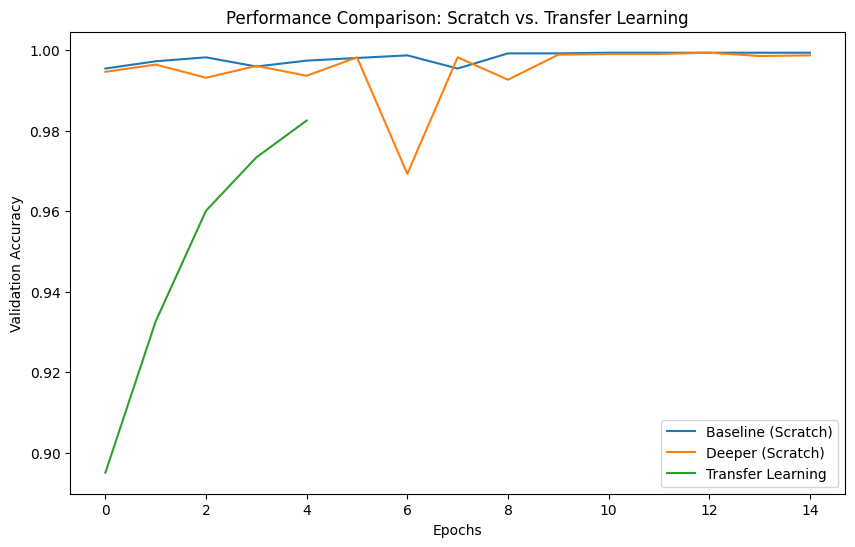

In [ ]:
# Final comparison of all 3 main models
print(f"Baseline Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Deeper Model Accuracy: {history_deeper.history['val_accuracy'][-1]:.4f}")
print(f"Transfer Learning Accuracy: {history_finetune.history['val_accuracy'][-1]:.4f}")

# Plotting the three
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Baseline (Scratch)')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper (Scratch)')
plt.plot(history_finetune.history['val_accuracy'], label='Transfer Learning')
plt.title('Performance Comparison: Scratch vs. Transfer Learning')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

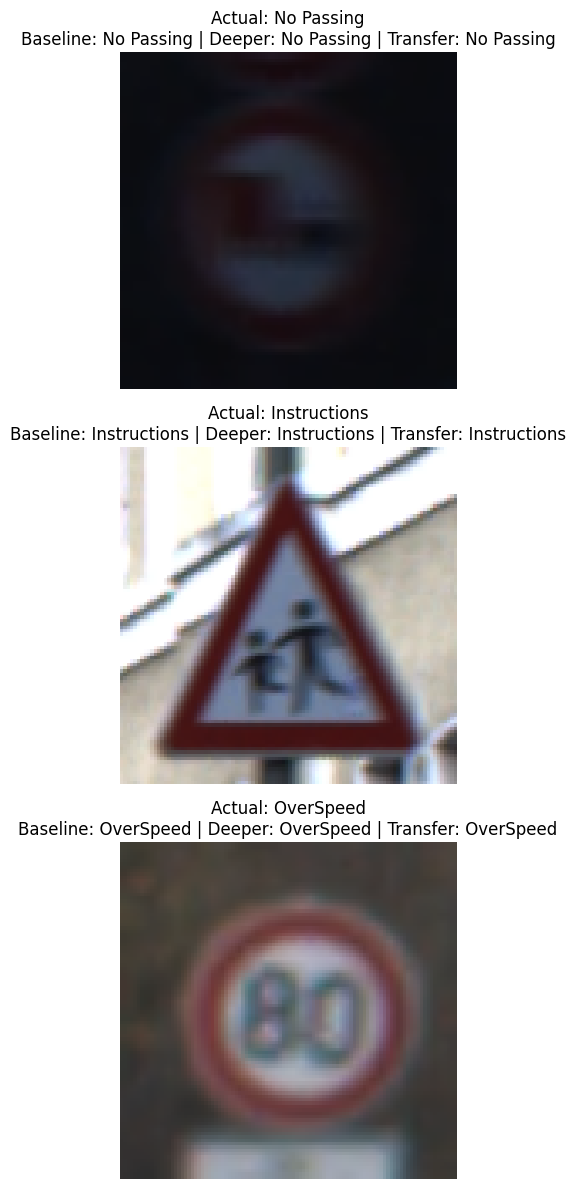

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get batch
image_batch, label_batch = next(iter(val_ds))

# Predictions
preds_baseline = baseline_model.predict(image_batch, verbose=0)
preds_deeper = deeper_model.predict(image_batch, verbose=0)
preds_transfer = transfer_model.predict(image_batch, verbose=0)

plt.figure(figsize=(15, 12))

for i in range(3):

    plt.subplot(3, 1, i + 1)


    img = image_batch[i].numpy()

    # ensure proper display range
    if img.max() > 1:
        img = img / 255.0

    img = np.clip(img, 0, 1)

    plt.imshow(img)

    actual = classes[np.argmax(label_batch[i])]

    b_pred = classes[np.argmax(preds_baseline[i])]
    d_pred = classes[np.argmax(preds_deeper[i])]
    t_pred = classes[np.argmax(preds_transfer[i])]

    plt.title(
        f"Actual: {actual}\n"
        f"Baseline: {b_pred} | Deeper: {d_pred} | Transfer: {t_pred}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true_transfer = []
y_pred_transfer = []

for images, labels in val_ds:
    preds_transfer_report = transfer_model.predict(images, verbose=0)
    y_true_transfer.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_transfer.extend(np.argmax(preds_transfer_report, axis=1))

print("\n--- Fine-Tuned Transfer Learning Model Classification Report ---")
print(classification_report(y_true_transfer, y_pred_transfer, target_names=class_names))


--- Fine-Tuned Transfer Learning Model Classification Report ---
              precision    recall  f1-score   support

     Caution       0.96      0.99      0.98      1261
Instructions       0.99      0.96      0.98      1338
  No Passing       0.99      0.99      0.99      1933
   OverSpeed       0.98      0.99      0.99      1583

    accuracy                           0.98      6115
   macro avg       0.98      0.98      0.98      6115
weighted avg       0.98      0.98      0.98      6115



Test

In [ ]:
import os
import re

test_dir = '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign/Test'

# Get all image files from the Test folder
test_images = [f for f in os.listdir(test_dir)
               if os.path.isfile(os.path.join(test_dir, f))]

test_images.sort()

clean_test_images = [re.sub(r'\.png$', '', c).strip() for c in test_images]

print(f"Total test images: {len(clean_test_images)}")

Total test images: 4


In [ ]:
import tensorflow as tf

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(100, 100),
    batch_size=32,
    label_mode=None,
    shuffle=False
)

test_ds = test_ds.map(lambda x: normalization(x))

Found 4 files.


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing import image

test_dir = '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Traffic_Sign/Test'

# Get all test images
test_images = sorted(os.listdir(test_dir))

y_pred_test = []
image_names = []

# Loop through images and predict
for img_name in test_images:
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(100, 100))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = transfer_model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds)

    y_pred_test.append(pred_class)
    image_names.append(img_name)

# Save predictions to CSV (IMPORTANT for reports/submission)
results = pd.DataFrame({
    'image': image_names,
    'predicted_class': y_pred_test
})

results.to_csv('test_predictions.csv', index=False)

print("✅ Prediction completed!")
print("Saved as test_predictions.csv")

✅ Prediction completed!
Saved as test_predictions.csv


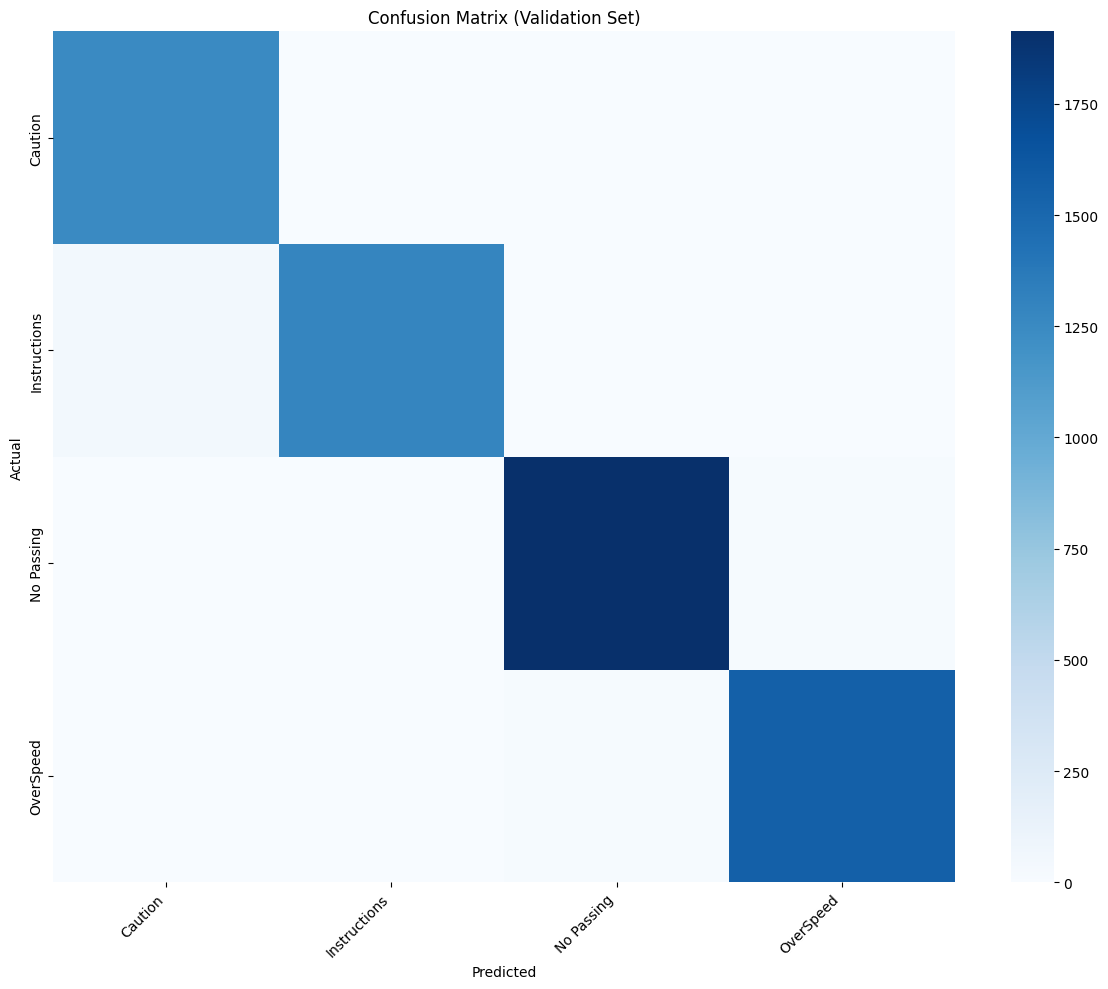

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": ["Baseline", "Deeper", "Transfer Learning"],
    "Val Accuracy": [
        history.history['val_accuracy'][-1],
        history_deeper.history['val_accuracy'][-1],
        history_finetune.history['val_accuracy'][-1]
    ],
    "Val Loss": [
        history.history['val_loss'][-1],
        history_deeper.history['val_loss'][-1],
        history_finetune.history['val_loss'][-1]
    ]
})

print(final_results)

               Model  Val Accuracy  Val Loss
0           Baseline      0.999346  0.006923
1             Deeper      0.998692  0.004963
2  Transfer Learning      0.982502  0.051417
